# Student Performance Analysis

## Project Workflow

1. Business Objective
2. Data Loading and Cleaning
3. Exploratory Data Analysis
4. Feature Engineering
5. Statistical Analysis
6. Machine Learning Modeling
7. Model Evaluation
8. Feature Importance
9. Project Conclusions & Recommendations


## Business Objective
Identify the academic and family-related factors that most influence student performance
and use predictive modeling to support early academic intervention.

## Data Loading and Cleaning


#### IMPORTS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.titlesize': 16, 'axes.titlesize': 14, 'axes.labelsize': 12})

#### READ CSV

In [3]:
df=pd.read_csv("student_score.csv")
print(df.head())

   Unnamed: 0  Gender EthnicGroup          ParentEduc     LunchType TestPrep  \
0           0  female         NaN   bachelor's degree      standard     none   
1           1  female     group C        some college      standard      NaN   
2           2  female     group B     master's degree      standard     none   
3           3    male     group A  associate's degree  free/reduced     none   
4           4    male     group C        some college      standard     none   

  ParentMaritalStatus PracticeSport IsFirstChild  NrSiblings TransportMeans  \
0             married     regularly          yes         3.0     school_bus   
1             married     sometimes          yes         0.0            NaN   
2              single     sometimes          yes         4.0     school_bus   
3             married         never           no         1.0            NaN   
4             married     sometimes          yes         0.0     school_bus   

  WklyStudyHours  MathScore  ReadingScore  W

In [4]:
print("\nDataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape: (30641, 15)

Columns:
['Unnamed: 0', 'Gender', 'EthnicGroup', 'ParentEduc', 'LunchType', 'TestPrep', 'ParentMaritalStatus', 'PracticeSport', 'IsFirstChild', 'NrSiblings', 'TransportMeans', 'WklyStudyHours', 'MathScore', 'ReadingScore', 'WritingScore']

Missing Values:
Unnamed: 0                0
Gender                    0
EthnicGroup            1840
ParentEduc             1845
LunchType                 0
TestPrep               1830
ParentMaritalStatus    1190
PracticeSport           631
IsFirstChild            904
NrSiblings             1572
TransportMeans         3134
WklyStudyHours          955
MathScore                 0
ReadingScore              0
WritingScore              0
dtype: int64


In [5]:
df.describe()



,Unnamed: 0,NrSiblings,MathScore,ReadingScore,WritingScore
count,30641.000000,29069.000000,30641.000000,30641.000000,30641.000000
mean,499.556607,2.145894,66.558402,69.377533,68.418622
std,288.747894,1.458242,15.361616,14.758952,15.443525
min,0.000000,0.000000,0.000000,10.000000,4.000000
25%,249.000000,1.000000,56.000000,59.000000,58.000000
50%,500.000000,2.000000,67.000000,70.000000,69.000000
75%,750.000000,3.000000,78.000000,80.000000,79.000000
max,999.000000,7.000000,100.000000,100.000000,100.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30641 non-null  int64  
 1   Gender               30641 non-null  object 
 2   EthnicGroup          28801 non-null  object 
 3   ParentEduc           28796 non-null  object 
 4   LunchType            30641 non-null  object 
 5   TestPrep             28811 non-null  object 
 6   ParentMaritalStatus  29451 non-null  object 
 7   PracticeSport        30010 non-null  object 
 8   IsFirstChild         29737 non-null  object 
 9   NrSiblings           29069 non-null  float64
 10  TransportMeans       27507 non-null  object 
 11  WklyStudyHours       29686 non-null  object 
 12  MathScore            30641 non-null  int64  
 13  ReadingScore         30641 non-null  int64  
 14  WritingScore         30641 non-null  int64  
dtypes: float64(1), int64(4), object(10)


#### CLEANING

In [7]:
df.isnull().sum()

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

df["NrSiblings"] = df["NrSiblings"].fillna(df["NrSiblings"].median())

df = df.drop(columns=["Unnamed: 0"], errors="ignore")

In [8]:

print(df.head())

   Gender EthnicGroup          ParentEduc     LunchType TestPrep  \
0  female     group C   bachelor's degree      standard     none   
1  female     group C        some college      standard     none   
2  female     group B     master's degree      standard     none   
3    male     group A  associate's degree  free/reduced     none   
4    male     group C        some college      standard     none   

  ParentMaritalStatus PracticeSport IsFirstChild  NrSiblings TransportMeans  \
0             married     regularly          yes         3.0     school_bus   
1             married     sometimes          yes         0.0     school_bus   
2              single     sometimes          yes         4.0     school_bus   
3             married         never           no         1.0     school_bus   
4             married     sometimes          yes         0.0     school_bus   

  WklyStudyHours  MathScore  ReadingScore  WritingScore  
0            < 5         71            71            74  


Missing values were handled using mode imputation for categorical variables and median imputation for numerical variables. The unnecessary index column was removed before analysis.

## Exploratory Data Analysis

#### Gender Distribution

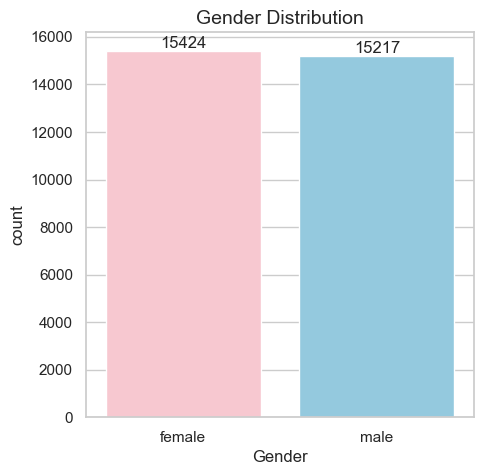

In [9]:
#gender distribution
plt.figure(figsize=(5,5))
plt.title("Gender Distribution")
ax = sns.countplot(
    data=df,
    x="Gender",
    hue="Gender",
    palette={"male": "skyblue", "female": "pink"},
    legend=False
)

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.show()


From the above chart, the number of females in the data is slightly higher than the number of males.

#### Parent Education Analysis

In [10]:
gp0=df.groupby("ParentEduc").agg({"MathScore":'mean',"ReadingScore":'mean',"WritingScore":'mean'})
print(gp0)

                    MathScore  ReadingScore  WritingScore
ParentEduc                                               
associate's degree  68.365586     71.124324     70.299099
bachelor's degree   70.466627     73.062020     73.331069
high school         64.435731     67.213997     65.421136
master's degree     72.336134     75.832921     76.356896
some college        66.445978     69.189667     68.456711
some high school    62.584013     65.510785     63.632409


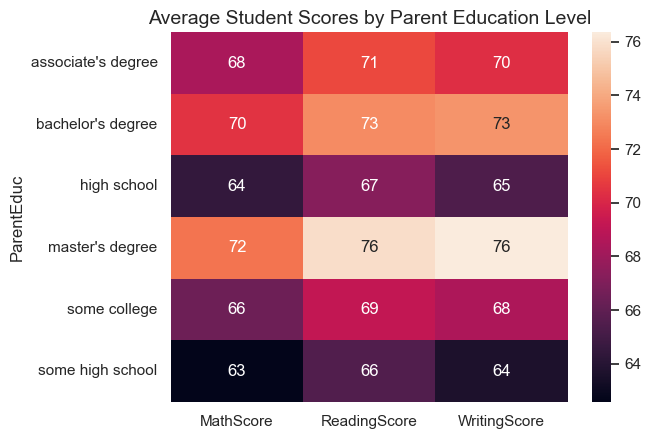

In [11]:
sns.heatmap(gp0,annot=True)
plt.title("Average Student Scores by Parent Education Level")
plt.show()

From the above chart, we can see that parents' education has an impact on student scores.

student whose parents have higher education levels usually score better, especially in reading and writing

#### Parent Marital Status Analysis

In [12]:
gp1=df.groupby("ParentMaritalStatus").agg({"MathScore":'mean',"ReadingScore":'mean',"WritingScore":'mean'})
print(gp1)

                     MathScore  ReadingScore  WritingScore
ParentMaritalStatus                                       
divorced             66.691197     69.655011     68.799146
married              66.650161     69.379561     68.406177
single               66.165704     69.157250     68.174440
widowed              67.368866     69.651438     68.563452


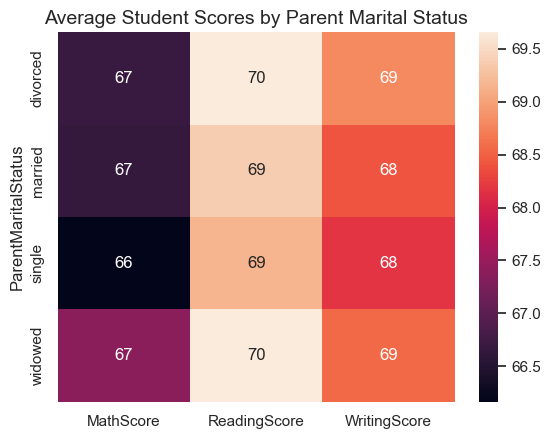

In [13]:
sns.heatmap(gp1,annot=True)
plt.title("Average Student Scores by Parent Marital Status")
plt.show()

Parent marital status has little or no impact on student scores.


#### Subject-wise Score Distribution

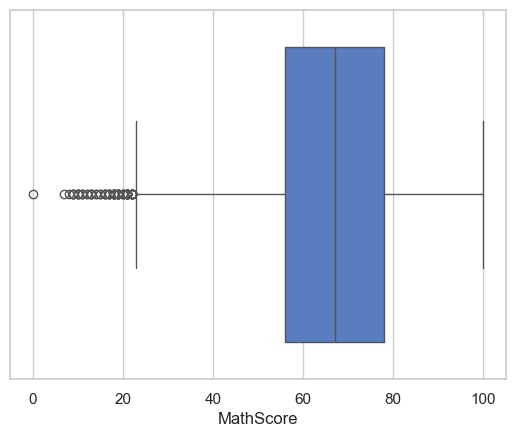

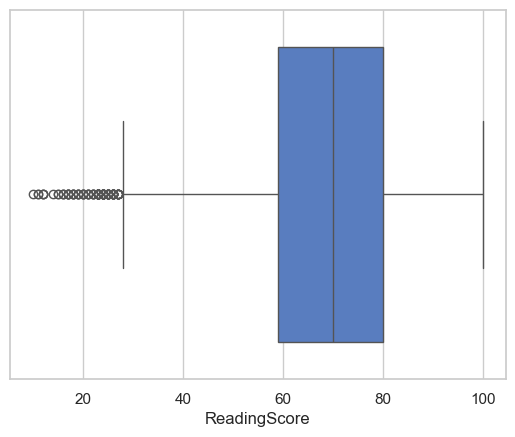

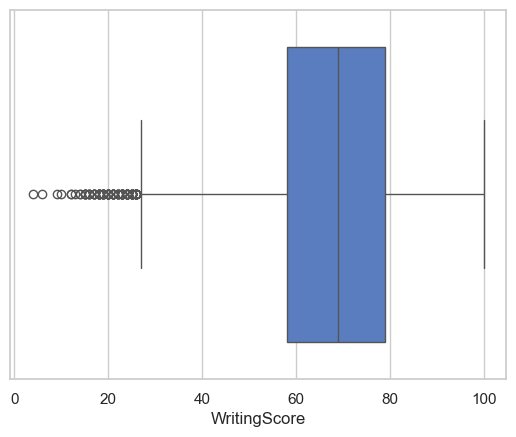

In [14]:

sns.boxplot(data=df,x="MathScore")
plt.show()
sns.boxplot(data=df,x="ReadingScore")
plt.show()
sns.boxplot(data=df,x="WritingScore")
plt.show()


Math appears to be relatively more difficult than reading and writing.


## Feature Engineering

#### Creating Performance Features

New features are created to better represent students' overall academic performance and enable more meaningful analysis and prediction.

In [15]:
df["TotalScore"] = df["MathScore"] + df["ReadingScore"] + df["WritingScore"]

In [16]:
df["AvgScore"] = df["TotalScore"] / 3

df["Performance"] = pd.cut(
    df["AvgScore"],
    bins=[0, 50, 70, 85, 100],
    labels=["Poor", "Average", "Good", "Excellent"]
)

#### Standardized Score (Z-Score)

In [17]:
df["ZScore"] = (
    df["TotalScore"] - df["TotalScore"].mean()
) / df["TotalScore"].std()

df[["TotalScore", "ZScore"]].head()

,TotalScore,ZScore
0,216,0.268557
1,247,0.983453
2,271,1.536920
3,143,-1.414906
4,229,0.568352


## Exploratory Analysis of Engineered Features

In [18]:
print(df["TotalScore"].describe())

count    30641.000000
mean       204.354558
std         43.362980
min         27.000000
25%        175.000000
50%        205.000000
75%        236.000000
max        300.000000
Name: TotalScore, dtype: float64


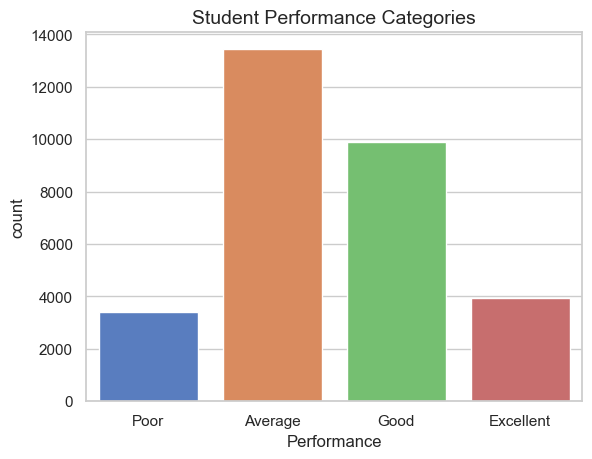

In [19]:
sns.countplot(
    data=df,
    x="Performance",
    hue="Performance",
    legend=False
)

plt.title("Student Performance Categories")
plt.show()

#### Total Score Distribution

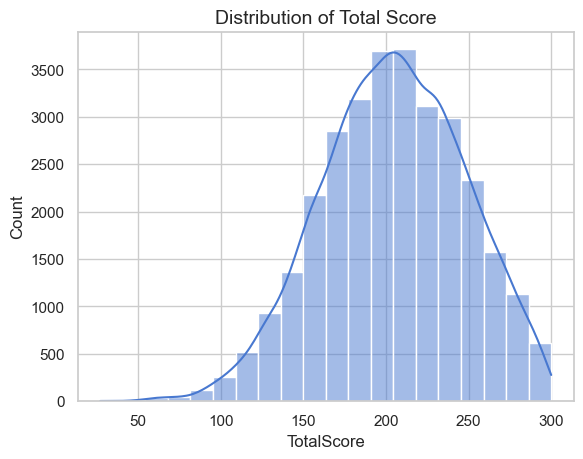

In [20]:
sns.histplot(df["TotalScore"], bins=20, kde=True)
plt.title("Distribution of Total Score")
plt.show()

Most students score in the middle range, with fewer students scoring extremely high or low.

Total score gives an overall idea of student performance instead of looking at each subject separately

#### Total Score by Gender

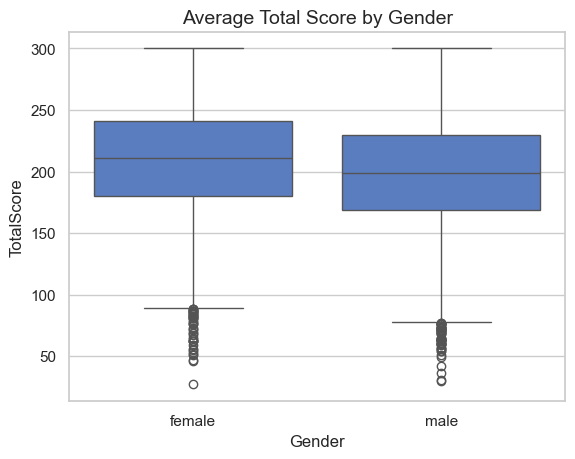

In [21]:
sns.boxplot(data=df, x="Gender", y="TotalScore")
plt.title("Average Total Score by Gender")
plt.show()

The total scores of male and female students are quite close, but females have a slightly higher median score.
This means both genders perform almost equally in academics.

#### Correlation Analysis

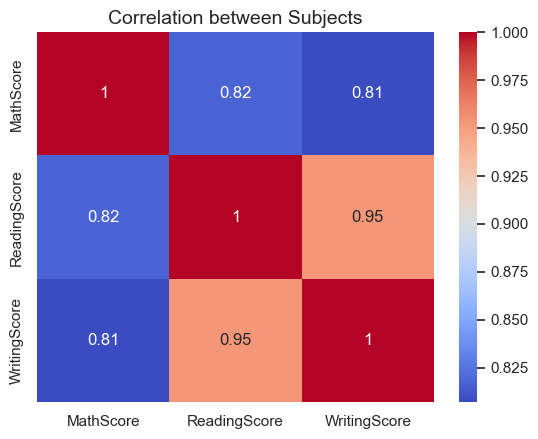

In [22]:
corr = df[["MathScore","ReadingScore","WritingScore"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation between Subjects")
plt.show()

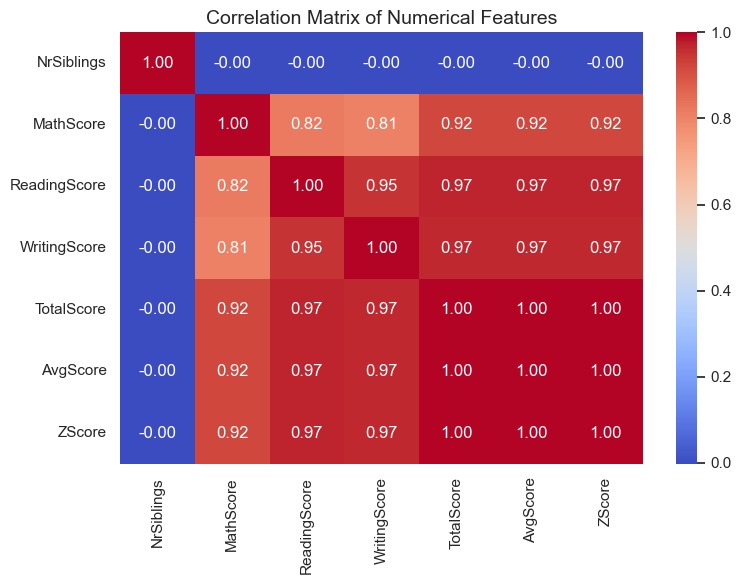

In [23]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

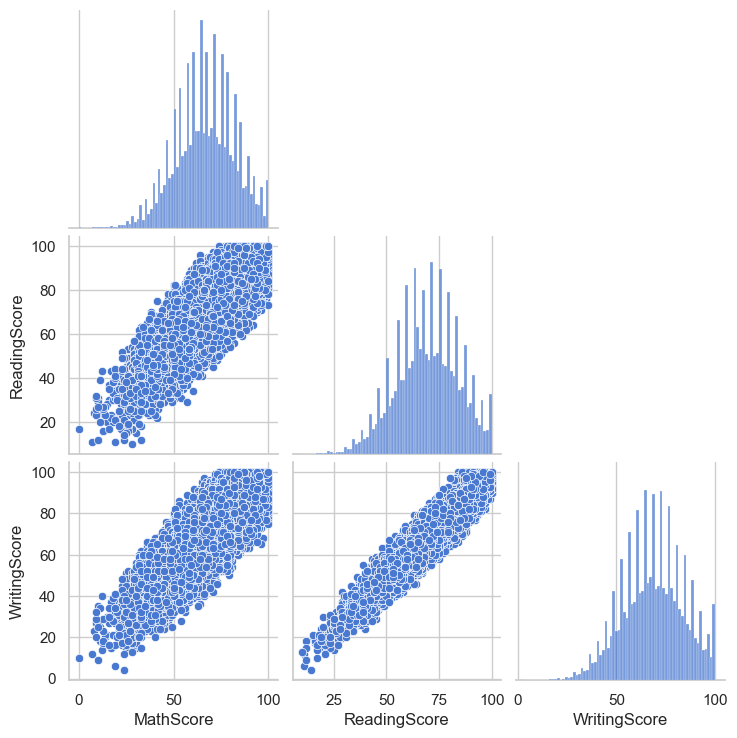

In [24]:
sns.pairplot(
    df[
        ["MathScore",
         "ReadingScore",
         "WritingScore"]
    ],
    corner=True
)

plt.show()

Reading and Writing exhibit the strongest positive correlation, indicating that students who perform well in one language-based subject tend to perform well in the other. Mathematics is positively correlated with both subjects but to a slightly lesser extent.

## Statistical Analysis

### Statistical Hypothesis Testing

To validate whether the observed differences in student performance are statistically significant, hypothesis testing techniques are applied.

#### Effect of Test Preparation

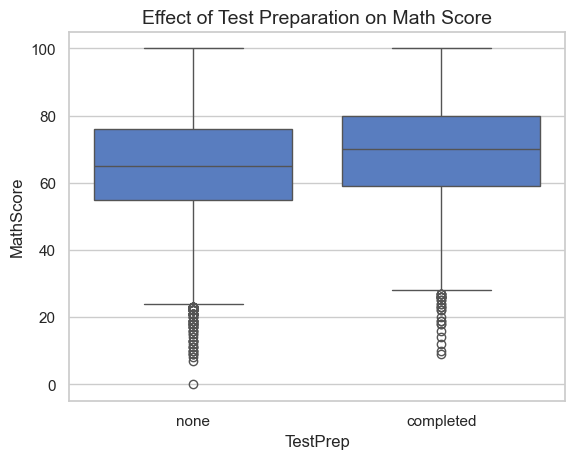

In [25]:
sns.boxplot(data=df,x="TestPrep",y="MathScore")
plt.title("Effect of Test Preparation on Math Score")
plt.show()

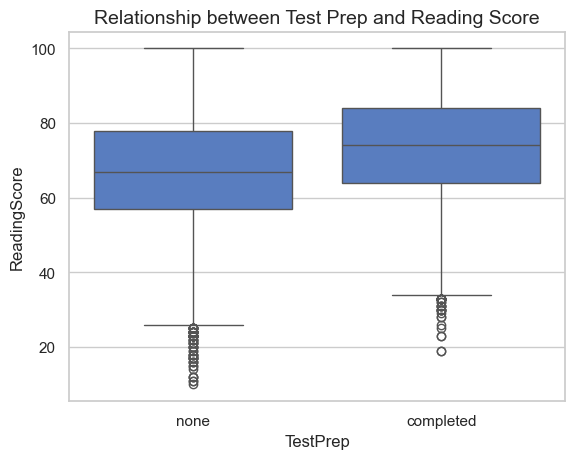

In [26]:
sns.boxplot(data=df,x="TestPrep",y="ReadingScore")
plt.title("Relationship between Test Prep and Reading Score")
plt.show()

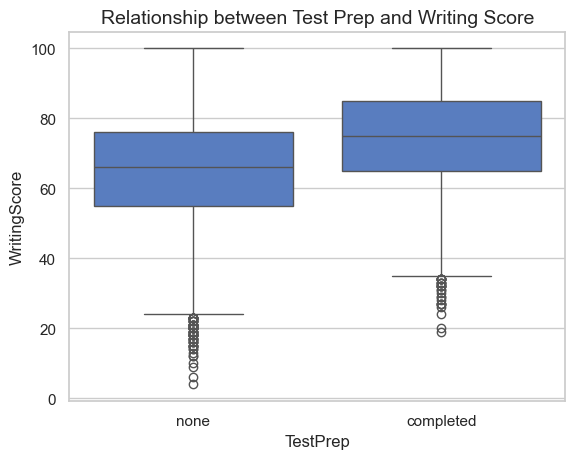

In [27]:
sns.boxplot(data=df,x="TestPrep",y="WritingScore")
plt.title("Relationship between Test Prep and Writing Score")
plt.show()

In [28]:
prep_scores = df.groupby("TestPrep")["TotalScore"].mean()
print(prep_scores)

improvement = (
    (prep_scores["completed"] - prep_scores["none"]) /
    prep_scores["none"]
) * 100

print(f"Score improvement due to test prep: {improvement:.2f}%")

TestPrep
completed    217.982923
none         197.795997
Name: TotalScore, dtype: float64
Score improvement due to test prep: 10.21%


#### Independent T-Test

In [29]:
from scipy.stats import ttest_ind

group_prep = df[df["TestPrep"] == "completed"]["TotalScore"]
group_no_prep = df[df["TestPrep"] == "none"]["TotalScore"]

t_stat, p_val = ttest_ind(group_prep, group_no_prep)
print(f"Statistical Significance (p-value): {p_val:.4f}")

if p_val < 0.05:
    print("Insight: The impact of test preparation is statistically significant.")

Statistical Significance (p-value): 0.0000
Insight: The impact of test preparation is statistically significant.


#### One-Way ANOVA

In [30]:
from scipy.stats import f_oneway

groups = [
    group["TotalScore"].values
    for _, group in df.groupby("ParentEduc")
]

f_stat, p_val = f_oneway(*groups)

print("\nANOVA Test")

print("F Statistic:", f_stat)
print("P Value:", p_val)

if p_val < 0.05:
    print("Parent education significantly affects performance.")
else:
    print("No significant impact found.")


ANOVA Test
F Statistic: 301.0778254719729
P Value: 1.11613616e-315
Parent education significantly affects performance.


#### Sports Activity and Performance


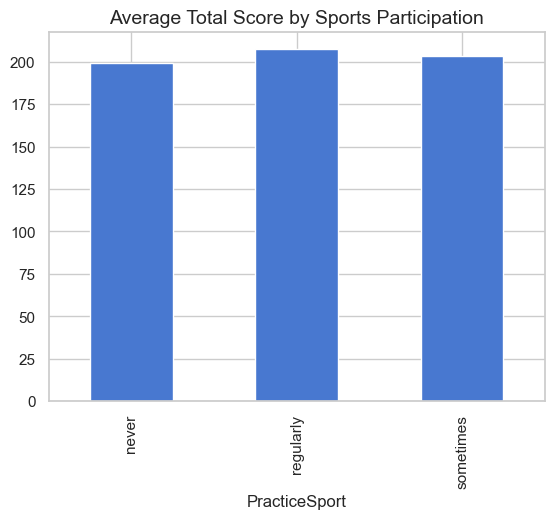

In [31]:
gp2 = df.groupby("PracticeSport")["TotalScore"].mean()
gp2.plot(kind="bar")
plt.title("Average Total Score by Sports Participation")
plt.show()

Students who regularly participate in sports tend to achieve slightly higher total scores, suggesting a positive relationship between extracurricular activity and academic performance.

#### Ethnic Group Distribution

In [32]:
print(df['EthnicGroup'].unique())

['group C' 'group B' 'group A' 'group D' 'group E']


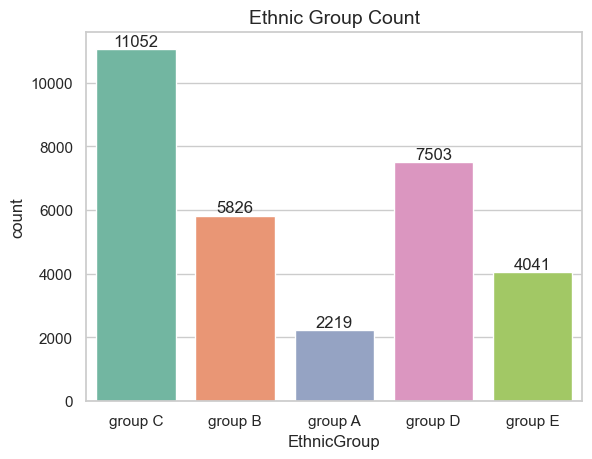

In [33]:
ax = sns.countplot(
    data=df,
    x="EthnicGroup",
    hue="EthnicGroup",
    palette="Set2",
    legend=False
)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Ethnic Group Count")
plt.show()

The distribution of students across different ethnic groups provides additional context for understanding the dataset.

## Machine Learning Modeling

After exploring the data and identifying important factors affecting student performance, machine learning models are developed to predict students' overall academic performance based on demographic, educational, and behavioral characteristics.

#### Data Preparation

The target variable is separated from the predictors, categorical variables are encoded, and the dataset is split into training and testing sets.

In [34]:

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    learning_curve,
    GridSearchCV
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
X = df.drop(
    columns=[
        "MathScore",
        "ReadingScore",
        "WritingScore",
        "TotalScore",
        "AvgScore",
        "Performance",
        "ZScore"
    ],
    errors="ignore"
)
y = df["TotalScore"]
X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)




#### Model Initialization

Three regression models are initialized to compare their ability to predict student performance.

In [35]:
models = {
    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(
            random_state=42
        )
}

#### Hyperparameter Tuning 

Grid Search Cross Validation is used to identify the optimal Random Forest parameters for improving predictive performance.

In [36]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

rf = grid_search.best_estimator_

print("Best Parameters")
print(grid_search.best_params_)

print("Best Cross-Validation R² Score:")
print(f"{grid_search.best_score_:.4f}")



Best Parameters
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validation R² Score:
0.2305


In [37]:
models["Tuned Random Forest"] = rf

## Model Evaluation

#### Results Table

The performance of each model is evaluated using R², MAE, and RMSE.

In [38]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    results.append([
        name,
        r2_score(y_test, pred),
        mean_absolute_error(y_test, pred),
        np.sqrt(mean_squared_error(y_test, pred))
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "R2", "MAE", "RMSE"]
)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
)
best_model = results_df.iloc[0]

print("\nBest Performing Model")
print(f"Model : {best_model['Model']}")
print(f"R²    : {best_model['R2']:.4f}")
print(f"MAE   : {best_model['MAE']:.2f}")
print(f"RMSE  : {best_model['RMSE']:.2f}")

print(results_df)
print("\nModel Ranking")
print(results_df[["Model", "R2"]])



Best Performing Model
Model : Linear Regression
R²    : 0.2587
MAE   : 30.02
RMSE  : 37.08
                 Model        R2        MAE       RMSE
0    Linear Regression  0.258694  30.022411  37.077950
2  Tuned Random Forest  0.235920  30.508112  37.643176
1        Decision Tree -0.464163  41.764985  52.108872

Model Ranking
                 Model        R2
0    Linear Regression  0.258694
2  Tuned Random Forest  0.235920
1        Decision Tree -0.464163


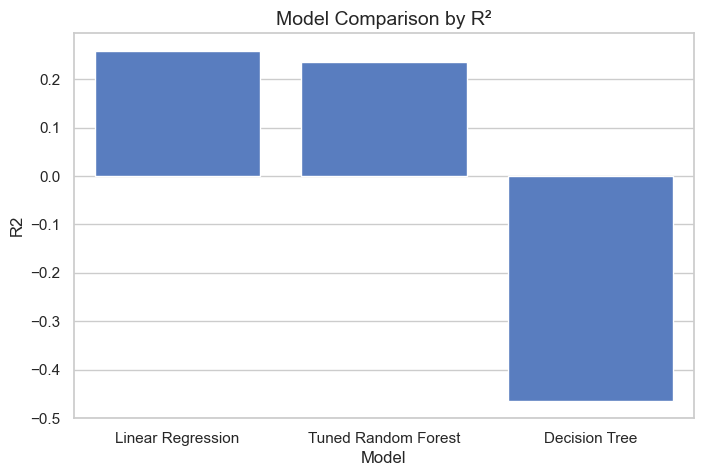

In [39]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="R2")
plt.title("Model Comparison by R²")
plt.show()

#### Cross Validation

Cross-validation is performed to evaluate how well each model generalizes to unseen data.

In [40]:
print("\nCross Validation Scores")

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_encoded,
        y,
        cv=5,
        scoring="r2"
    )

    print(f"{name}")
    print(f"Average R² : {scores.mean():.4f}")
    print(f"Standard Deviation : {scores.std():.4f}\n")


Cross Validation Scores
Linear Regression
Average R² : 0.2562
Standard Deviation : 0.0053

Decision Tree
Average R² : -0.4333
Standard Deviation : 0.0206

Tuned Random Forest
Average R² : 0.2354
Standard Deviation : 0.0058



#### Actual vs Predicted

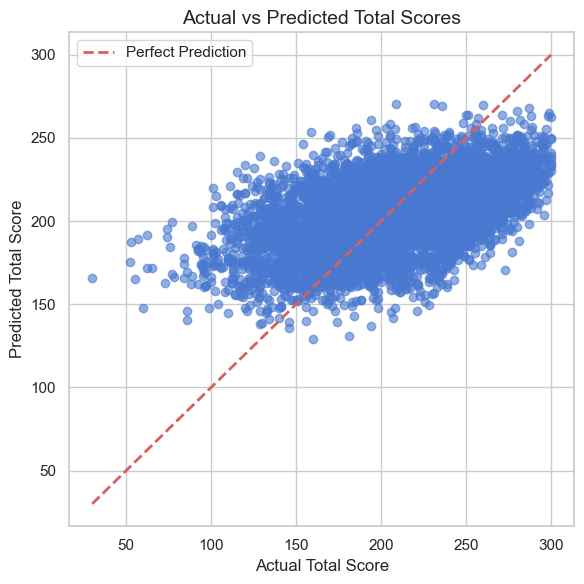

In [41]:
pred = rf.predict(X_test)

plt.figure(figsize=(6, 6))

plt.scatter(y_test, pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Total Score")
plt.ylabel("Predicted Total Score")
plt.title("Actual vs Predicted Total Scores")
plt.legend()
plt.tight_layout()
plt.show()

This plot compares the actual student scores with the model predictions. Points closer to the diagonal line indicate more accurate predictions.

## Feature Importance Analysis

#### Top 10 Important Features

Random Forest feature importance identifies the variables that contribute the most to predicting student performance.

In [42]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_encoded.columns
)

print("\nTop 10 Important Features")
print(importance.sort_values(ascending=False).head(10))


Top 10 Important Features
LunchType_standard             0.291348
TestPrep_none                  0.138327
EthnicGroup_group E            0.082247
NrSiblings                     0.067044
ParentEduc_some high school    0.061312
Gender_male                    0.051373
EthnicGroup_group D            0.034574
ParentEduc_master's degree     0.032544
ParentEduc_high school         0.031285
WklyStudyHours_< 5             0.024921
dtype: float64


#### Feature Importance Plot

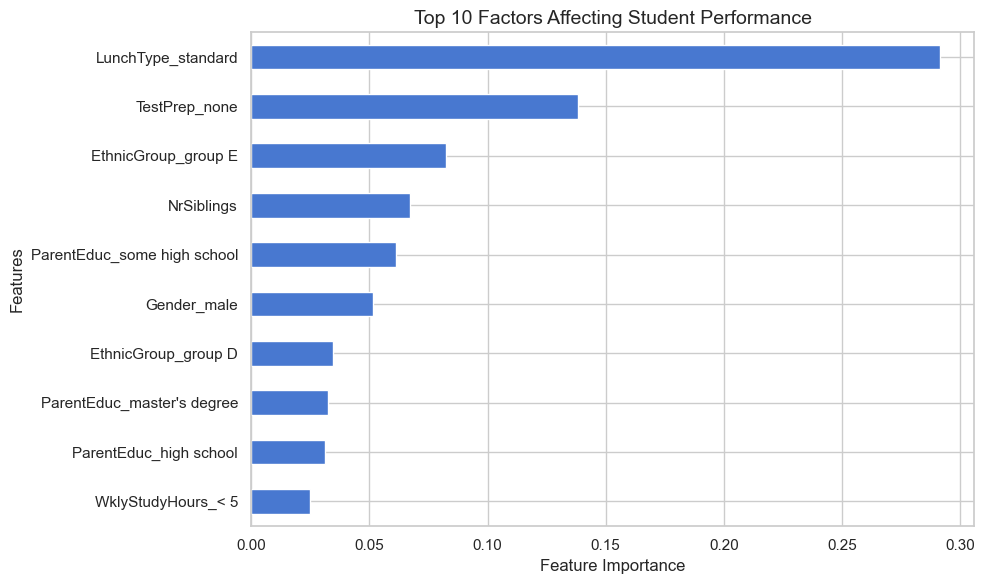

In [43]:
top_features = (
    importance
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10,6))

top_features.plot(
    kind="barh"
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Factors Affecting Student Performance")

plt.tight_layout()
plt.show()

## Model Diagnostics

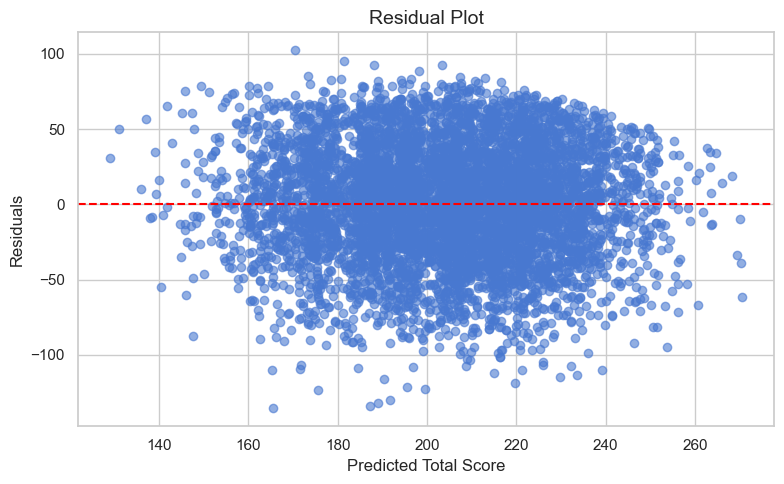

In [44]:
residuals = y_test - pred

plt.figure(figsize=(8,5))

plt.scatter(pred, residuals, alpha=0.6)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Total Score")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

The residuals are randomly scattered around zero, indicating that the Random Forest model does not show any obvious systematic prediction bias. This suggests that the model fits the data reasonably well.

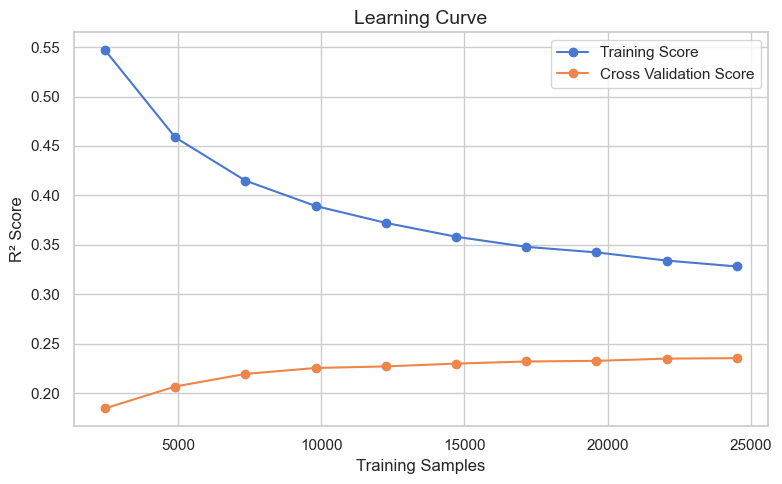

In [45]:
train_sizes, train_scores, test_scores = learning_curve(
    rf,
    X_encoded,
    y,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Score"
)

plt.plot(
    train_sizes,
    test_mean,
    marker="o",
    label="Cross Validation Score"
)

plt.xlabel("Training Samples")
plt.ylabel("R² Score")
plt.title("Learning Curve")

plt.legend()

plt.tight_layout()

plt.show()

The learning curve shows how model performance changes as more training data becomes available. As the training size increases, the training and validation scores converge, indicating that the model generalizes well without severe overfitting.

## Project Conclusions & Recommendations

#### Key Findings
1. Test preparation has a statistically significant positive impact on academic performance.

2. Parent education level significantly influences student outcomes.

3. Students involved in sports tend to achieve higher scores on average.

4. Reading and Writing scores exhibit a strong positive correlation.

5. Machine learning models can predict overall student performance using demographic and behavioral factors.

#### RECOMMENDATIONS
1. Encourage participation in test preparation programs.

2. Identify low-performing student groups early for intervention.

3. Promote extracurricular activities alongside academics.

4. Provide additional academic support for students from less advantaged educational backgrounds.

## Final Summary

This project demonstrates a complete data science workflow, beginning with data cleaning and exploratory analysis, followed by feature engineering, statistical hypothesis testing, predictive modeling, model evaluation, and business recommendations. The results highlight the importance of parental education, test preparation, and sports participation in influencing academic performance while demonstrating that machine learning can effectively identify students who may benefit from early academic intervention.